The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Epoch 0 with train loss: 0.38526695807774863 and eval loss: 0.19478468596935272
Epoch 1 with train loss: 0.21824570039908092 and eval loss: 0.18049552494093127
Epoch 2 with train loss: 0.17527157604694366 and eval loss: 0.16426032441465752
Epoch 3 with train loss: 0.1544118693470955 and eval loss: 0.16024754811888156
Epoch 4 with train loss: 0.1391368614633878 and eval loss: 0.13411630528128665
Epoch 5 with train loss: 0.12075923080245654 and eval loss: 0.13550736520277418
Epoch 6 with train loss: 0.11484850058952967 and eval loss: 0.1336471298304589
Epoch 7 with train loss: 0.11065992708007495 and eval loss: 0.12999246925439523
Epoch 8 with train loss: 0.10804158121347428 and eval loss: 0.12289621478513531
Epoch 9 with train loss: 0.10551956877112388 and eval loss: 0.12486453030420386
Epoch 10 with train loss: 0.10449505080779393 and eval loss: 0.12377431810550067
Epoch 11 with train loss: 0.103856

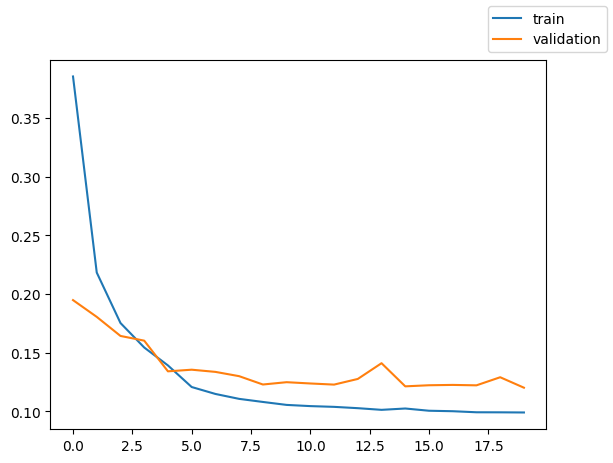

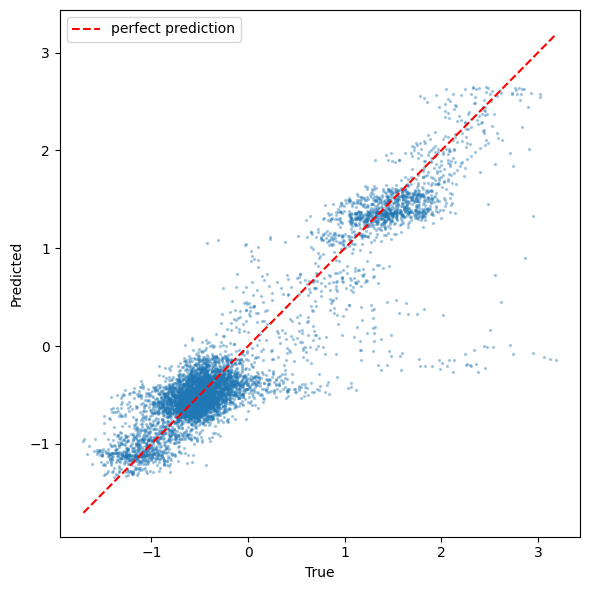

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pickle

%load_ext autoreload
%autoreload 2

from data_helpers import prepare_this_data, torchify_this_data
from model_stuff import model_setup

df = pd.read_csv('../data/CESMDataset_Try.csv')

target_col = 'AMOC'
feature_cols = ['SFWF', 'PD_200m']
lag = 100
horizon = 40
n = len(df)
train_cut_1 = 5000
train_cut_2 = 11000
batch_size = 128

X_train_lag, y_train_lag, X_eval_lag, y_eval_lag, y_scaler, x_scaler = prepare_this_data(df, 
                                                                                        target_col, 
                                                                                        feature_cols,
                                                                                        train_cut_1,
                                                                                        train_cut_2,
                                                                                        lag,
                                                                                        horizon)

X_train_t, y_train_t, train_loader, X_eval_t, y_eval_t, eval_loader = torchify_this_data(batch_size, 
                                                                                        X_train_lag, 
                                                                                        y_train_lag,                                                                                                       
                                                                                        X_eval_lag, 
                                                                                        y_eval_lag)
device = "cpu"
n_epochs = 20

params = {
    'n_features': len(feature_cols),
    'hidden_size': 64,
    'num_layers': 1,
    'dropout': 0.0,
    'lr': 1e-3,
    'loss_fn': nn.MSELoss()
}

NN_AMOC, train_losses, eval_losses = model_setup(device, params, n_epochs, train_loader, eval_loader, X_eval_t, y_eval_lag)

torch.save({
    'state_dict': NN_AMOC.state_dict(),
    'config': {
        'n_features': len(feature_cols),
        'hidden_size': 64,
        'num_layers': 1,
        'dropout': 0.0,
    },
}, 'amoc_model.pth')

with open('scalers_AMOC.pkl', 'wb') as f:
    pickle.dump({'y_scaler': y_scaler, 'x_scaler': x_scaler}, f)



In [3]:
len(df)

15796